In [1]:
# Bibliothèques standard
import os
import sys
import json
import zipfile
import random
import shutil
from datetime import datetime
from pathlib import Path

# Scientific / utils
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import requests

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import data as tf_data
import tensorflow as tf, subprocess
import keras

# MLflow
import mlflow
import mlflow.keras
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature, ModelSignature
from mlflow.types import Schema, ColSpec, TensorSpec


In [2]:
# === Imports principaux ===
import os, random
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tqdm import tqdm

import tensorflow as tf
from tensorflow import data as tf_data
from tensorflow.keras import layers, models, applications, callbacks, optimizers, losses

# === Config générale ===
ROOT = Path("/Users/anasesseddiki/Desktop/Projet8")
DATA_DIR = ROOT / "data"
IMG_DIR  = DATA_DIR / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
GT_DIR   = DATA_DIR / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE  = (256, 512)         # (H, W)
N_CLASSES = 8                  # segmentation 8 classes
BATCH     = 4

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs vus par TF :", gpus)
for d in gpus:
    try:
        print("  ->", tf.config.experimental.get_device_details(d))
    except Exception:
        pass


TensorFlow: 2.16.2
GPUs vus par TF : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  -> {'device_name': 'METAL'}


In [3]:
def count_pngs(d: Path, pattern: str) -> int:
    if not d.exists():
        return 0
    return len(list(d.rglob(pattern)))

splits = ["train", "val", "test"]
print("📁 Images :", IMG_DIR)
print("📁 Masks  :", GT_DIR)
print("\n📊 Comptes par split :")

for s in splits:
    c_img  = count_pngs(IMG_DIR / s, "*_leftImg8bit.png")
    c_tids = count_pngs(GT_DIR  / s, "*_gtFine_trainIds.png")
    c_lids = count_pngs(GT_DIR  / s, "*_gtFine_labelIds.png")
    c_col  = count_pngs(GT_DIR  / s, "*_gtFine_color.png")
    print(f"  - {s:5s} | images={c_img:4d} | trainIds={c_tids:4d} | labelIds={c_lids:4d} | color={c_col:4d}")


📁 Images : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit
📁 Masks  : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine

📊 Comptes par split :
  - train | images=2975 | trainIds=2975 | labelIds=2975 | color=2975
  - val   | images= 500 | trainIds= 500 | labelIds= 500 | color= 500
  - test  | images=1525 | trainIds=1525 | labelIds=1525 | color=1525


In [4]:
# LUT officielle Cityscapes : labelId -> trainId (255 = ignore)
LABELID_TO_TRAINID = {
     0:255,  1:255,  2:255,  3:255,  4:255,  5:255,  6:255,  # unlabeled...ground
     7:0,    8:1,                                            # road, sidewalk
     9:255, 10:255,                                          # parking, rail track (ignored)
    11:2,   12:3,   13:4,                                    # building, wall, fence
    14:255, 15:255, 16:255,                                  # guard rail, bridge, tunnel (ignored)
    17:5,   18:255,                                          # pole, polegroup (ignored)
    19:6,   20:7,                                            # traffic light, traffic sign
    21:8,   22:9,   23:10,                                   # vegetation, terrain, sky
    24:11,  25:12,                                           # person, rider
    26:13,  27:14,  28:15,                                   # car, truck, bus
    29:255, 30:255,                                          # caravan, trailer (ignored)
    31:16,  32:17,  33:18,                                   # train, motorcycle, bicycle
    34:255,                                                  # license plate (ignored)
}

lut = np.full(256, 255, dtype=np.uint8)
for k, v in LABELID_TO_TRAINID.items():
    lut[k] = v

from tqdm import tqdm

for split in ["train", "val", "test"]:
    split_dir = GT_DIR / split
    if not split_dir.exists():
        continue
    print(f"➡ Conversion labelIds -> trainIds sur split='{split}'")
    for city_dir in tqdm(sorted(split_dir.glob("*"))):
        for p in city_dir.glob("*_gtFine_labelIds.png"):
            out_path = p.with_name(p.name.replace("_gtFine_labelIds.png", "_gtFine_trainIds.png"))
            if out_path.exists():
                continue
            arr = np.array(Image.open(p))
            mapped = lut[arr]
            Image.fromarray(mapped, mode="L").save(out_path)

print("Génération des trainIds terminée.")


➡ Conversion labelIds -> trainIds sur split='train'


100%|█████████████████████████████████████████| 19/19 [00:00<00:00, 1003.54it/s]


➡ Conversion labelIds -> trainIds sur split='val'


100%|████████████████████████████████████████████| 3/3 [00:00<00:00, 900.58it/s]


➡ Conversion labelIds -> trainIds sur split='test'


100%|████████████████████████████████████████████| 7/7 [00:00<00:00, 753.75it/s]

Génération des trainIds terminée.


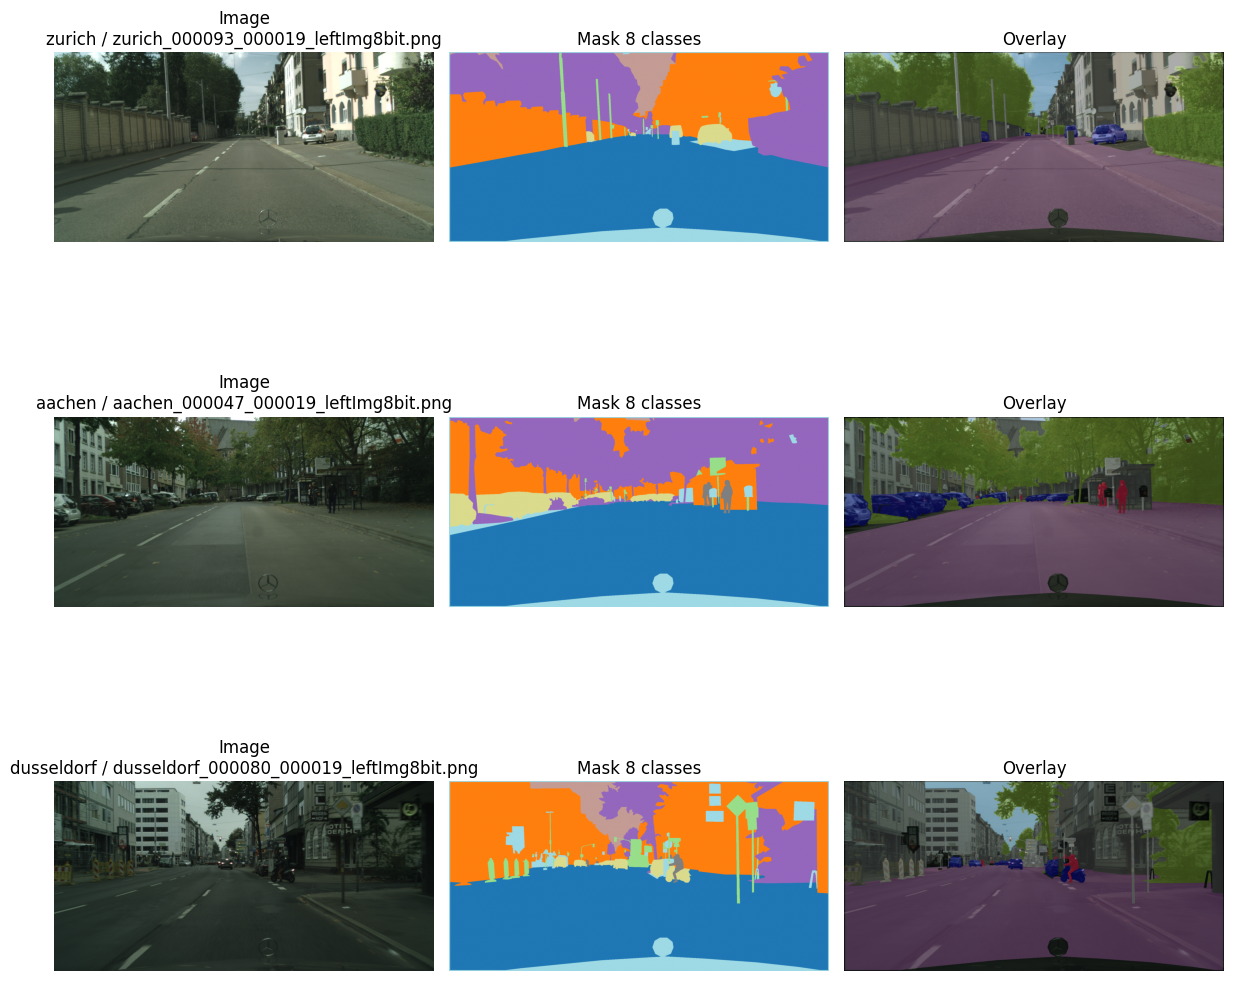

Classes 8c: ['flat', 'construction', 'object', 'nature', 'sky', 'human', 'vehicle', 'void']


In [5]:
# 8 classes fusionnées
CLASS_NAMES_8 = ["flat","construction","object","nature","sky","human","vehicle","void"]
PALETTE_8 = np.array([
    [128,  64, 128],  # flat
    [ 70,  70,  70],  # construction
    [153, 153, 153],  # object
    [107, 142,  35],  # nature
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # human
    [  0,   0, 142],  # vehicle
    [  0,   0,   0],  # void
], dtype=np.uint8)

# trainId -> 8 classes
TRAINID_TO_8 = {
     0:0, 1:0,
     2:1, 3:1, 4:1,
     5:2, 6:2, 7:2,
     8:3, 9:3,
    10:4,
    11:5, 12:5,
    13:6, 14:6, 15:6, 16:6, 17:6, 18:6,
   255:7,
}
LUT_T2_8 = np.full(256, 7, dtype=np.uint8)
for k,v in TRAINID_TO_8.items():
    LUT_T2_8[k] = v

def mask_trainIds_to_8c(mask_arr: np.ndarray) -> np.ndarray:
    """mask_arr: [H,W] trainIds -> [H,W] 0..7"""
    return LUT_T2_8[mask_arr]

def colorize_8c(mask8: np.ndarray) -> np.ndarray:
    return PALETTE_8[mask8]

def overlay(img_rgb: np.ndarray, mask_rgb: np.ndarray, alpha=0.45) -> np.ndarray:
    img = img_rgb.astype(np.float32)/255.0
    msk = mask_rgb.astype(np.float32)/255.0
    return np.clip((1-alpha)*img + alpha*msk, 0, 1)

# --- affichage de quelques exemples ---
SPLIT     = "train"
N_SAMPLES = 3
ALPHA     = 0.45

all_imgs = sorted((IMG_DIR / SPLIT).rglob("*_leftImg8bit.png"))
assert len(all_imgs) > 0, f"Aucune image trouvée sous {IMG_DIR/SPLIT}"
sample = random.sample(all_imgs, k=min(N_SAMPLES, len(all_imgs)))

fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4*len(sample)))
if len(sample) == 1:
    axes = np.expand_dims(axes, 0)

for row, img_path in enumerate(sample):
    base = img_path.name.replace("_leftImg8bit.png", "")
    city = img_path.parent.name
    mask_path = GT_DIR / SPLIT / city / f"{base}_gtFine_trainIds.png"

    img = np.array(Image.open(img_path).convert("RGB"))
    axes[row,0].imshow(img)
    axes[row,0].set_title(f"Image\n{city} / {img_path.name}")
    axes[row,0].axis("off")

    if not mask_path.exists():
        axes[row,1].text(0.5,0.5,"Masque introuvable", ha="center", va="center")
        axes[row,1].axis("off")
        axes[row,2].axis("off")
        continue

    m_arr = np.array(Image.open(mask_path))
    m8    = mask_trainIds_to_8c(m_arr)
    m8_rgb = colorize_8c(m8)
    axes[row,1].imshow(m8, cmap="tab20"); axes[row,1].set_title("Mask 8 classes"); axes[row,1].axis("off")
    axes[row,2].imshow(overlay(img, m8_rgb, ALPHA)); axes[row,2].set_title("Overlay"); axes[row,2].axis("off")

plt.tight_layout(); plt.show()
print("Classes 8c:", CLASS_NAMES_8)


In [6]:
# LUT 256 -> 8 (TensorFlow)
LUT_256_TO_8 = np.full(256, 7, dtype=np.uint8)
for k, v in TRAINID_TO_8.items():
    LUT_256_TO_8[k] = v
LUT_256_TO_8_T = tf.constant(LUT_256_TO_8, dtype=tf.uint8)

def list_images(split: str) -> list[Path]:
    return sorted((IMG_DIR / split).rglob("*_leftImg8bit.png"))

def to_mask_path(img_path: Path) -> Path:
    base  = img_path.name.replace("_leftImg8bit.png", "")
    city  = img_path.parent.name
    split = img_path.parent.parent.name
    return GT_DIR / split / city / f"{base}_gtFine_trainIds.png"

def decode_image(path: tf.Tensor, size: tuple[int,int]) -> tf.Tensor:
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=3)
    x = tf.image.convert_image_dtype(x, tf.float32)  # [0,1]
    if size:
        x = tf.image.resize(x, size, method="bilinear")
    return x

def decode_mask_8c(path: tf.Tensor, size: tuple[int,int]) -> tf.Tensor:
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=1)          # trainIds
    if size:
        x = tf.image.resize(x, size, method="nearest")
    x = tf.squeeze(x, -1)                           # [H,W]
    x = tf.gather(LUT_256_TO_8_T, tf.cast(x, tf.int32))
    return tf.expand_dims(x, -1)                    # [H,W,1]

def augment(img, msk):
    flip = tf.random.uniform([]) > 0.5
    img  = tf.cond(flip, lambda: tf.image.flip_left_right(img), lambda: img)
    msk  = tf.cond(flip, lambda: tf.image.flip_left_right(msk), lambda: msk)
    img  = tf.image.random_brightness(img, 0.05)
    img  = tf.image.random_contrast(img, 0.95, 1.05)
    return tf.clip_by_value(img, 0.0, 1.0), msk

def make_dataset(split: str,
                 img_size=(256, 512),
                 batch_size=4,
                 shuffle=True,
                 augment_data=True) -> tf.data.Dataset:
    img_paths_py = list_images(split)
    msk_paths_py = [to_mask_path(p) for p in img_paths_py]
    pairs = [(str(i), str(m)) for i, m in zip(img_paths_py, msk_paths_py) if m.exists()]
    if not pairs:
        raise RuntimeError(f"Aucun couple image/mask trouvé pour split='{split}'.")
    imgs, msks = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(imgs), list(msks)))
    if shuffle:
        ds = ds.shuffle(len(pairs), reshuffle_each_iteration=True)
    def _load(i, m):
        return decode_image(i, img_size), decode_mask_8c(m, img_size)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset("train", img_size=IMG_SIZE, batch_size=BATCH, shuffle=True,  augment_data=True)
val_ds   = make_dataset("val",   img_size=IMG_SIZE, batch_size=BATCH, shuffle=False, augment_data=False)

2025-11-08 00:32:19.545629: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-08 00:32:19.545652: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-11-08 00:32:19.545659: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-11-08 00:32:19.545673: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-08 00:32:19.545681: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [13]:
def dice_soft_macro(y_true, y_pred, eps=1e-6):
    """
    Dice macro moyen sur les N_CLASSES.
    y_true : [B,H,W,1] entiers (0..N_CLASSES-1)
    y_pred : [B,H,W,N_CLASSES] probabilités
    """
    y_true = tf.squeeze(tf.cast(y_true, tf.int32), -1)             # [B,H,W]
    y_true = tf.one_hot(y_true, depth=N_CLASSES, dtype=tf.float32) # [B,H,W,N_CLASSES]
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0)
    inter  = tf.reduce_sum(y_true * y_pred, axis=[1,2])            # [B,N_CLASSES]
    den    = tf.reduce_sum(y_true + y_pred, axis=[1,2])            # [B,N_CLASSES]
    dice   = (2.0 * inter + eps) / (den + eps)
    return tf.reduce_mean(dice)


In [8]:
def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def unet_mini(input_shape=IMG_SIZE + (3,), base=32, num_classes=N_CLASSES):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, base)       ; p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1,    base*2)      ; p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2,    base*4)      ; p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3,    base*8)      ; p4 = layers.MaxPool2D()(c4)
    bn = conv_block(p4, base*16)
    u4 = layers.UpSampling2D()(bn)      ; u4 = layers.Concatenate()([u4, c4]); c5 = conv_block(u4, base*8)
    u3 = layers.UpSampling2D()(c5)      ; u3 = layers.Concatenate()([u3, c3]); c6 = conv_block(u3, base*4)
    u2 = layers.UpSampling2D()(c6)      ; u2 = layers.Concatenate()([u2, c2]); c7 = conv_block(u2, base*2)
    u1 = layers.UpSampling2D()(c7)      ; u1 = layers.Concatenate()([u1, c1]); c8 = conv_block(u1, base)
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c8)
    return models.Model(inputs, outputs, name="UNetMini_8c")

model1 = unet_mini()
model1.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt1 = str(MODELS_DIR / "unet_mini_8c.keras")
cbs1 = [
    callbacks.ModelCheckpoint(ckpt1, save_best_only=True, monitor="val_dice_soft_macro", mode="max", verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=8, restore_best_weights=True, verbose=1),
]

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cbs1,
)

print("Modèle 1 (UNet-mini) sauvegardé ->", ckpt1)


Epoch 1/10


2025-11-08 00:32:21.159316: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.3996 - loss: 0.7899 - sparse_categorical_accuracy: 0.7505
Epoch 1: val_dice_soft_macro improved from -inf to 0.48327, saving model to /Users/anasesseddiki/Desktop/Projet8/models/unet_mini_8c.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 1059s 1s/step - dice_soft_macro: 0.3997 - loss: 0.7897 - sparse_categorical_accuracy: 0.7506 - val_dice_soft_macro: 0.4833 - val_loss: 0.7996 - val_sparse_categorical_accuracy: 0.7632 - learning_rate: 0.0010
Epoch 2/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.5336 - loss: 0.4789 - sparse_categorical_accuracy: 0.8481
Epoch 2: val_dice_soft_macro improved from 0.48327 to 0.53165, saving model to /Users/anasesseddiki/Desktop/Projet8/models/unet_mini_8c.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 1073s 1s/step - dice_soft_macro: 0.5336 - loss: 0.4788 - sparse_categorical_accuracy: 0.8481 - val_dice_soft_macro: 0.5316 - val_loss: 0.5534 - val_sparse_categorical_accuracy: 0.8355 - learning_rate: 0.0

In [9]:
def build_unet_mobilenetv2(input_shape=IMG_SIZE + (3,), n_classes=N_CLASSES):
    base_model = applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )
    skips = [
        base_model.get_layer(name).output
        for name in ["block_1_expand_relu",
                     "block_3_expand_relu",
                     "block_6_expand_relu",
                     "block_13_expand_relu"]
    ]
    x = base_model.output

    for skip in reversed(skips):
        x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(n_classes, 1, activation="softmax")(x)
    return models.Model(inputs=base_model.input, outputs=outputs, name="UNet_MobileNetV2")

model2 = build_unet_mobilenetv2()
model2.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt2 = str(MODELS_DIR / "unet_mobilenetv2_8c.keras")
cbs2 = [
    callbacks.ModelCheckpoint(ckpt2, save_best_only=True, monitor="val_dice_soft_macro", mode="max", verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=8, restore_best_weights=True, verbose=1),
]

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cbs2,
)
print("Modèle 2 (UNet+MobileNetV2) sauvegardé ->", ckpt2)


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_39411/988338402.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


Epoch 1/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - dice_soft_macro: 0.4713 - loss: 0.6343 - sparse_categorical_accuracy: 0.8012 
Epoch 1: val_dice_soft_macro improved from -inf to 0.54337, saving model to /Users/anasesseddiki/Desktop/Projet8/models/unet_mobilenetv2_8c.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 7826s 11s/step - dice_soft_macro: 0.4714 - loss: 0.6341 - sparse_categorical_accuracy: 0.8013 - val_dice_soft_macro: 0.5434 - val_loss: 0.5204 - val_sparse_categorical_accuracy: 0.8416 - learning_rate: 1.0000e-04
Epoch 2/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.6330 - loss: 0.3143 - sparse_categorical_accuracy: 0.8966
Epoch 2: val_dice_soft_macro improved from 0.54337 to 0.58565, saving model to /Users/anasesseddiki/Desktop/Projet8/models/unet_mobilenetv2_8c.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 986s 1s/step - dice_soft_macro: 0.6330 - loss: 0.3143 - sparse_categorical_accuracy: 0.8966 - val_dice_soft_macro: 0.5856 - val_loss: 0.5230 - val_sparse_categorical_accura

In [10]:
def aspp_static(x, filters=256, rates=(6, 12, 18), target_hw=(16, 32), name="aspp"):
    ys = []
    b0 = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_conv1x1")(x)
    b0 = layers.BatchNormalization(name=f"{name}_bn1x1")(b0); b0 = layers.ReLU()(b0); ys.append(b0)
    for r in rates:
        b = layers.SeparableConv2D(filters, 3, padding="same", dilation_rate=r, use_bias=False,
                                   name=f"{name}_sep3x3_r{r}")(x)
        b = layers.BatchNormalization(name=f"{name}_bn_r{r}")(b); b = layers.ReLU()(b); ys.append(b)
    ip = layers.GlobalAveragePooling2D(keepdims=True, name=f"{name}_gap")(x)
    ip = layers.Conv2D(filters, 1, use_bias=False, name=f"{name}_img_conv")(ip)
    ip = layers.BatchNormalization(name=f"{name}_img_bn")(ip); ip = layers.ReLU()(ip)
    ip = layers.Resizing(target_hw[0], target_hw[1], interpolation="bilinear", name=f"{name}_img_resize")(ip)
    ys.append(ip)
    y = layers.Concatenate(name=f"{name}_concat")(ys)
    y = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_proj")(y)
    y = layers.BatchNormalization(name=f"{name}_proj_bn")(y); y = layers.ReLU()(y)
    y = layers.Dropout(0.1, name=f"{name}_drop")(y)
    return y

def deeplabv3p_mnv2(input_shape=IMG_SIZE + (3,), n_classes=N_CLASSES,
                    freeze_backbone=True, alpha=1.0,
                    aspp_filters=256, dec_filters=256, low_proj=64, dropout_decoder=0.1):
    inputs = layers.Input(shape=input_shape, name="input")
    base = applications.MobileNetV2(input_tensor=inputs, include_top=False, weights="imagenet", alpha=alpha)
    if freeze_backbone:
        base.trainable = False

    low = base.get_layer("block_3_expand_relu").output
    x   = base.get_layer("block_13_expand_relu").output

    h16 = input_shape[0] // 16
    w16 = input_shape[1] // 16

    x = aspp_static(x, filters=aspp_filters, rates=(6, 12, 18), target_hw=(h16, w16), name="aspp")
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear", name="aspp_up4")(x)

    low = layers.Conv2D(low_proj, 1, padding="same", use_bias=False, name="low_proj")(low)
    low = layers.BatchNormalization(name="low_bn")(low); low = layers.ReLU()(low)

    x = layers.Concatenate(name="decoder_concat")([x, low])
    x = layers.SeparableConv2D(dec_filters, 3, padding="same", use_bias=False, name="dec_sep1")(x)
    x = layers.BatchNormalization(name="dec_bn1")(x); x = layers.ReLU()(x)
    x = layers.SeparableConv2D(dec_filters, 3, padding="same", use_bias=False, name="dec_sep2")(x)
    x = layers.BatchNormalization(name="dec_bn2")(x); x = layers.ReLU()(x)
    if dropout_decoder and dropout_decoder > 0:
        x = layers.Dropout(dropout_decoder, name="decoder_drop")(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear", name="final_up4")(x)
    outputs = layers.Conv2D(n_classes, 1, activation="softmax", name="classifier")(x)
    return models.Model(inputs, outputs, name="DeepLabV3Plus_MNV2_Robust")

# --- Entraînement en 2 phases ---
EPOCHS_WARM = 10
EPOCHS_FT   = 20
LR_WARM     = 2e-4
LR_FT       = 1e-5
UNFREEZE_TAIL_LAYERS = 40

train_ds_pref = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds_pref   = val_ds.prefetch(tf.data.AUTOTUNE)

model3 = deeplabv3p_mnv2(alpha=1.0, aspp_filters=256, dec_filters=256, low_proj=64, dropout_decoder=0.1)
model3.compile(
    optimizer=optimizers.Adam(LR_WARM),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt3 = str(MODELS_DIR / "deeplabv3p_mnv2_full.keras")
cbs3 = [
    callbacks.ModelCheckpoint(ckpt3, save_best_only=True, monitor="val_dice_soft_macro", mode="max", verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=8, restore_best_weights=True, verbose=1),
]

print(" Warm-up (backbone gelé) ...")
hist_warm = model3.fit(
    train_ds_pref,
    validation_data=val_ds_pref,
    epochs=EPOCHS_WARM,
    callbacks=cbs3,
    verbose=1,
)

print(f" Fine-tuning : on dégèle les {UNFREEZE_TAIL_LAYERS} dernières couches du backbone...")
backbone = None
for layer in model3.layers:
    if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
        backbone = layer
        break
if backbone is None:
    for layer in model3.layers:
        if isinstance(layer, tf.keras.Model):
            backbone = layer
            break

if backbone is not None:
    for l in backbone.layers[-UNFREEZE_TAIL_LAYERS:]:
        l.trainable = True
else:
    for l in model3.layers[-UNFREEZE_TAIL_LAYERS:]:
        if hasattr(l, "trainable"):
            l.trainable = True

model3.compile(
    optimizer=optimizers.Adam(LR_FT),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

hist_ft = model3.fit(
    train_ds_pref,
    validation_data=val_ds_pref,
    epochs=EPOCHS_FT,
    callbacks=cbs3,
    verbose=1,
)

eval_full = model3.evaluate(val_ds_pref, verbose=0)
print(
    f"\nDeepLabV3+ (robuste) — metrics val:\n"
    f"  - loss = {eval_full[0]:.4f}\n"
    f"  - acc  = {eval_full[1]:.4f}\n"
    f"  - dice = {eval_full[2]:.4f}"
)
print("Modèle 3 (DeepLabV3+) sauvegardé ->", ckpt3)


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_39411/1054792168.py:24: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = applications.MobileNetV2(input_tensor=inputs, include_top=False, weights="imagenet", alpha=alpha)


 Warm-up (backbone gelé) ...
Epoch 1/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - dice_soft_macro: 0.4686 - loss: 0.6464 - sparse_categorical_accuracy: 0.7903
Epoch 1: val_dice_soft_macro improved from -inf to 0.55150, saving model to /Users/anasesseddiki/Desktop/Projet8/models/deeplabv3p_mnv2_full.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 343s 456ms/step - dice_soft_macro: 0.4687 - loss: 0.6462 - sparse_categorical_accuracy: 0.7904 - val_dice_soft_macro: 0.5515 - val_loss: 0.4094 - val_sparse_categorical_accuracy: 0.8624 - learning_rate: 2.0000e-04
Epoch 2/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - dice_soft_macro: 0.5894 - loss: 0.3789 - sparse_categorical_accuracy: 0.8704
Epoch 2: val_dice_soft_macro improved from 0.55150 to 0.60697, saving model to /Users/anasesseddiki/Desktop/Projet8/models/deeplabv3p_mnv2_full.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 336s 452ms/step - dice_soft_macro: 0.5894 - loss: 0.3789 - sparse_categorical_accuracy: 0.8704 - val_dice_soft_macro: 0.6070 - val_loss:

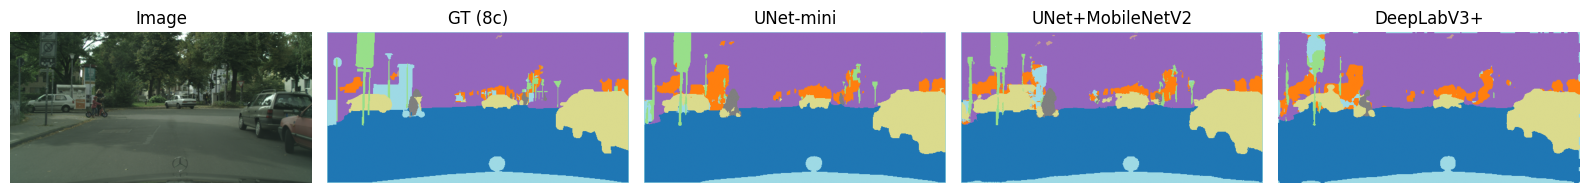

Image : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/val/munster/munster_000101_000019_leftImg8bit.png
Masque trainIds : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/val/munster/munster_000101_000019_gtFine_trainIds.png


In [11]:
import random

model1 = tf.keras.models.load_model(MODELS_DIR / "unet_mini_8c.keras",
                                    custom_objects={"dice_soft_macro": dice_soft_macro})
model2 = tf.keras.models.load_model(MODELS_DIR / "unet_mobilenetv2_8c.keras",
                                    custom_objects={"dice_soft_macro": dice_soft_macro})
model3 = tf.keras.models.load_model(MODELS_DIR / "deeplabv3p_mnv2_full.keras",
                                    custom_objects={"dice_soft_macro": dice_soft_macro})

sample_imgs = sorted((IMG_DIR / "val").rglob("*_leftImg8bit.png"))
img_path = random.choice(sample_imgs)
base = img_path.name.replace("_leftImg8bit.png", "")
city = img_path.parent.name
mask_path = GT_DIR / "val" / city / f"{base}_gtFine_trainIds.png"

img = Image.open(img_path).convert("RGB").resize((IMG_SIZE[1], IMG_SIZE[0]))
mask_true = Image.open(mask_path).resize((IMG_SIZE[1], IMG_SIZE[0]), Image.NEAREST)

img_np  = np.array(img)
mask_np = np.array(mask_true)
mask8   = mask_trainIds_to_8c(mask_np)

x = img_np[np.newaxis, ...] / 255.0

pred1 = np.argmax(model1.predict(x, verbose=0), axis=-1)[0]
pred2 = np.argmax(model2.predict(x, verbose=0), axis=-1)[0]
pred3 = np.argmax(model3.predict(x, verbose=0), axis=-1)[0]

plt.figure(figsize=(16,6))
plt.subplot(1,5,1); plt.imshow(img_np); plt.title("Image"); plt.axis("off")
plt.subplot(1,5,2); plt.imshow(mask8, cmap="tab20"); plt.title("GT (8c)"); plt.axis("off")
plt.subplot(1,5,3); plt.imshow(pred1, cmap="tab20"); plt.title("UNet-mini"); plt.axis("off")
plt.subplot(1,5,4); plt.imshow(pred2, cmap="tab20"); plt.title("UNet+MobileNetV2"); plt.axis("off")
plt.subplot(1,5,5); plt.imshow(pred3, cmap="tab20"); plt.title("DeepLabV3+"); plt.axis("off")
plt.tight_layout(); plt.show()

print("Image :", img_path)
print("Masque trainIds :", mask_path)


Évaluation sur le jeu de validation...



,Modèle,Loss,Accuracy,Dice
0,UNet-Mini,0.3078,0.8986,0.6650
1,UNet-MobileNetV2,0.3309,0.8941,0.6653
2,DeepLabV3+ (robuste),0.3676,0.8853,0.6501


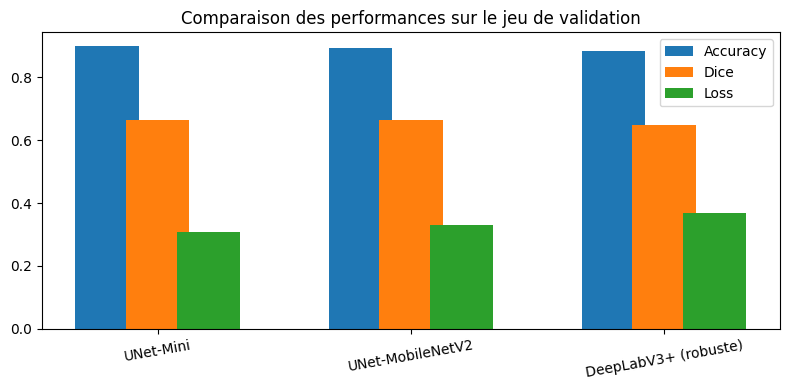


🏆 Le meilleur modèle sur validation est **UNet-MobileNetV2** (Dice=0.665, Acc=0.894).


In [14]:
# === Comparaison quantitative des 3 modèles sur val_ds ===

# Rechargement (si non déjà faits)
model1 = tf.keras.models.load_model(MODELS_DIR / "unet_mini_8c.keras",
                                    custom_objects={"dice_soft_macro": dice_soft_macro})
model2 = tf.keras.models.load_model(MODELS_DIR / "unet_mobilenetv2_8c.keras",
                                    custom_objects={"dice_soft_macro": dice_soft_macro})
model3 = tf.keras.models.load_model(MODELS_DIR / "deeplabv3p_mnv2_full.keras",
                                    custom_objects={"dice_soft_macro": dice_soft_macro})

# Évaluation sur val_ds
print("Évaluation sur le jeu de validation...\n")
eval1 = model1.evaluate(val_ds, verbose=0)
eval2 = model2.evaluate(val_ds, verbose=0)
eval3 = model3.evaluate(val_ds, verbose=0)

# Organisation des résultats
import pandas as pd

results = pd.DataFrame({
    "Modèle": ["UNet-Mini", "UNet-MobileNetV2", "DeepLabV3+ (robuste)"],
    "Loss":   [eval1[0], eval2[0], eval3[0]],
    "Accuracy": [eval1[1], eval2[1], eval3[1]],
    "Dice":   [eval1[2], eval2[2], eval3[2]],
}).round(4)

display(results)

# Visualisation graphique
plt.figure(figsize=(8,4))
x = np.arange(len(results))
plt.bar(x-0.2, results["Accuracy"], 0.25, label="Accuracy")
plt.bar(x,     results["Dice"],     0.25, label="Dice")
plt.bar(x+0.2, results["Loss"],     0.25, label="Loss")
plt.xticks(x, results["Modèle"], rotation=10)
plt.title("Comparaison des performances sur le jeu de validation")
plt.legend()
plt.tight_layout()
plt.show()

# Interprétation automatique
best_idx = results["Dice"].idxmax()
best_model = results.loc[best_idx, "Modèle"]
print(f"\n🏆 Le meilleur modèle sur validation est **{best_model}** "
      f"(Dice={results.loc[best_idx,'Dice']:.3f}, "
      f"Acc={results.loc[best_idx,'Accuracy']:.3f}).")


##### Validation de la configuration matérielle et s’assurer que TensorFlow utilise bien l’accélération GPU sur macOS.

# Ce que voit TensorFlow (GPU Metal)
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("TF GPUs:", gpus)
for d in gpus:
    print("TF GPU details:", tf.config.experimental.get_device_details(d))

#  Modèle exact côté macOS (system_profiler)
out = subprocess.run(
    ["system_profiler", "SPDisplaysDataType"],
    capture_output=True, text=True
).stdout
for line in out.splitlines():
    if ("Chipset Model:" in line) or ("VRAM" in line) or ("Metal" in line):
        print(line.strip())


#####  Vérification que toutes les données nécessaires sont bien présentes et bien structurées avant de lancer la préparation ou l’entraînement du modèle.

# Racine de tes données (suivant ta capture)
ROOT_CS = Path("/Users/anasesseddiki/Desktop/Projet8/data")

# Chemins exacts (avec le niveau P8_Cityscapes_*)
IMG_DIR = ROOT_CS / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
GT_DIR  = ROOT_CS / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"

# Comptages rapides
def count_pngs(d: Path, pattern: str) -> int:
    return len(list(d.rglob(pattern))) if d.exists() else 0

splits = ["train", "val", "test"]
counts = {
    s: {
        "images":      count_pngs(IMG_DIR / s, "*_leftImg8bit.png"),
        "gt_trainIds": count_pngs(GT_DIR  / s, "*_gtFine_trainIds.png"),
        "gt_labelIds": count_pngs(GT_DIR  / s, "*_gtFine_labelIds.png"),
        "gt_color":    count_pngs(GT_DIR  / s, "*_gtFine_color.png"),
    }
    for s in splits
}

print("📁 Images :", IMG_DIR)
print("📁 Masks  :", GT_DIR)
print("\n📊 Comptes par split:")
for s in splits:
    c = counts[s]
    print(f"  - {s:5s} | images={c['images']:4d} | trainIds={c['gt_trainIds']:4d} | labelIds={c['gt_labelIds']:4d} | color={c['gt_color']:4d}")


##### On convertit les masques Cityscapes bruts en masques d’entraînement normalisés, prêts à être utilisés par le modèle de segmentation.

# Dossier gtFine exact (suivant ton arborescence)
GT_DIR = Path("/Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine")

# LUT officielle Cityscapes : labelId -> trainId (255 = ignore)
LABELID_TO_TRAINID = {
     0:255,  1:255,  2:255,  3:255,  4:255,  5:255,  6:255,  # unlabeled...ground
     7:0,    8:1,                                            # road, sidewalk
     9:255, 10:255,                                          # parking, rail track (ignored)
    11:2,   12:3,   13:4,                                    # building, wall, fence
    14:255, 15:255, 16:255,                                  # guard rail, bridge, tunnel (ignored)
    17:5,   18:255,                                          # pole, polegroup (ignored)
    19:6,   20:7,                                            # traffic light, traffic sign
    21:8,   22:9,   23:10,                                   # vegetation, terrain, sky
    24:11,  25:12,                                           # person, rider
    26:13,  27:14,  28:15,                                   # car, truck, bus
    29:255, 30:255,                                          # caravan, trailer (ignored)
    31:16,  32:17,  33:18,                                   # train, motorcycle, bicycle
    34:255,                                                  # license plate (ignored)
}

# Construire LUT 256 valeurs
lut = np.full(256, 255, dtype=np.uint8)
for k, v in LABELID_TO_TRAINID.items():
    lut[k] = v

# Conversion labelIds -> trainIds pour train/val/test
for split in ["train", "val", "test"]:
    split_dir = GT_DIR / split
    if not split_dir.exists():
        continue
    for city_dir in sorted(split_dir.glob("*")):
        for p in city_dir.glob("*_gtFine_labelIds.png"):
            arr = np.array(Image.open(p))
            mapped = lut[arr]  # map vectorisée
            out_path = p.with_name(p.name.replace("_gtFine_labelIds.png", "_gtFine_trainIds.png"))
            Image.fromarray(mapped, mode="L").save(out_path)
print("Génération des trainIds terminée.")


##### Vérification de nombre d’images et de masques disponibles par split, pour s’assurer que rien ne manque avant l’entraînement

IMG_DIR = Path("/Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit")
GT_DIR  = Path("/Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine")

def count_pngs(d: Path, pattern: str) -> int:
    return len(list(d.rglob(pattern)))

for s in ["train", "val", "test"]:
    img_n  = count_pngs(IMG_DIR / s, "*_leftImg8bit.png")
    tr_n   = count_pngs(GT_DIR  / s, "*_gtFine_trainIds.png")
    lab_n  = count_pngs(GT_DIR  / s, "*_gtFine_labelIds.png")
    col_n  = count_pngs(GT_DIR  / s, "*_gtFine_color.png")
    print(f"{s:5s} | images={img_n:4d} | trainIds={tr_n:4d} | labelIds={lab_n:4d} | color={col_n:4d}")


##### Exploration et visualisation le dataset Cityscapes en 8 classes simplifiées, pour vérifier que les masques correspondent bien aux images.

from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- chemins (réutilise IMG_DIR/GT_DIR si déjà définis ; sinon, fixe-les ici)
try:
    IMG_DIR
    GT_DIR
except NameError:
    ROOT_CS = Path("/Users/anasesseddiki/Desktop/Projet8/data")
    IMG_DIR = ROOT_CS / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
    GT_DIR  = ROOT_CS / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"

SPLIT      = "train"     # "train" | "val"
N_SAMPLES  = 3           # nb d’exemples à afficher
ALPHA      = 0.45        # transparence du mask sur l’overlay

# --- classes 8c + palette ---
CLASS_NAMES_8 = ["flat","construction","object","nature","sky","human","vehicle","void"]
PALETTE_8 = np.array([
    [128,  64, 128],  # flat
    [ 70,  70,  70],  # construction
    [153, 153, 153],  # object
    [107, 142,  35],  # nature
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # human
    [  0,   0, 142],  # vehicle
    [  0,   0,   0],  # void
], dtype=np.uint8)

# --- LUTs ---
# labelId -> trainId (officiel Cityscapes)
LABELID_TO_TRAINID = {
     0:255,  1:255,  2:255,  3:255,  4:255,  5:255,  6:255,
     7:0,    8:1,
     9:255, 10:255,
    11:2,   12:3,   13:4,
    14:255, 15:255, 16:255,
    17:5,   18:255,
    19:6,   20:7,
    21:8,   22:9,   23:10,
    24:11,  25:12,
    26:13,  27:14,  28:15,
    29:255, 30:255,
    31:16,  32:17,  33:18,
    34:255,
}
LUT_L2T = np.full(256, 255, dtype=np.uint8)
for k,v in LABELID_TO_TRAINID.items(): LUT_L2T[k] = v

# trainId -> 8 classes
TRAINID_TO_8 = {
     0:0, 1:0,
     2:1, 3:1, 4:1,
     5:2, 6:2, 7:2,
     8:3, 9:3,
    10:4,
    11:5, 12:5,
    13:6, 14:6, 15:6, 16:6, 17:6, 18:6,
   255:7,
}
LUT_T2_8 = np.full(256, 7, dtype=np.uint8)
for k,v in TRAINID_TO_8.items(): LUT_T2_8[k] = v

# --- helpers ---
def find_mask_for(img_path: Path):
    base = img_path.name.replace("_leftImg8bit.png", "")
    city = img_path.parent.name
    split = img_path.parent.parent.name
    m_train = GT_DIR / split / city / f"{base}_gtFine_trainIds.png"
    m_label = GT_DIR / split / city / f"{base}_gtFine_labelIds.png"
    m_color = GT_DIR / split / city / f"{base}_gtFine_color.png"
    if m_train.exists(): return m_train, "trainIds"
    if m_label.exists(): return m_label, "labelIds"
    if m_color.exists(): return m_color, "color"
    return None, None

def to_8classes(mask_img: Image.Image, kind: str) -> np.ndarray:
    arr = np.array(mask_img)
    if kind == "color":
        # pas d’indice → on garde tel quel pour affichage brut et on met tout en void (rarement utile)
        return np.full(arr.shape[:2], 7, dtype=np.uint8)
    if arr.ndim == 3:  # si jamais
        arr = arr[...,0]
    if kind == "labelIds":
        arr = LUT_L2T[arr]      # -> trainIds
    # kind == "trainIds" maintenant
    return LUT_T2_8[arr]        # -> 0..7

def colorize_8c(mask8: np.ndarray) -> np.ndarray:
    return PALETTE_8[mask8]     # [H,W,3] RGB

def overlay(img_rgb: np.ndarray, mask_rgb: np.ndarray, alpha=0.45) -> np.ndarray:
    img = img_rgb.astype(np.float32) / 255.0
    msk = mask_rgb.astype(np.float32) / 255.0
    return np.clip((1-alpha)*img + alpha*msk, 0, 1)

# --- sélection & affichage ---
all_imgs = sorted((IMG_DIR / SPLIT).rglob("*_leftImg8bit.png"))
assert len(all_imgs) > 0, f"Aucune image trouvée sous {IMG_DIR/SPLIT}"
sample = random.sample(all_imgs, k=min(N_SAMPLES, len(all_imgs)))

fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4*len(sample)))
if len(sample) == 1: axes = np.expand_dims(axes, 0)

for row, img_path in enumerate(sample):
    mask_path, kind = find_mask_for(img_path)
    img = np.array(Image.open(img_path).convert("RGB"))
    axes[row,0].imshow(img); axes[row,0].set_title(f"Image\n{img_path.parent.name} / {img_path.name}"); axes[row,0].axis("off")

    if mask_path is None:
        axes[row,1].text(0.5,0.5,"Mask introuvable", ha="center", va="center"); axes[row,1].axis("off")
        axes[row,2].axis("off")
        continue

    m_img = Image.open(mask_path)
    m8 = to_8classes(m_img, kind)                  # [H,W] 0..7
    m8_rgb = colorize_8c(m8)                       # [H,W,3]
    axes[row,1].imshow(m8, cmap="tab20"); axes[row,1].set_title(f"Mask 8 classes ({kind})"); axes[row,1].axis("off")
    axes[row,2].imshow(overlay(img, m8_rgb, ALPHA)); axes[row,2].set_title("Overlay"); axes[row,2].axis("off")

plt.tight_layout(); plt.show()

print("Classes 8c:", CLASS_NAMES_8)


##### On automatise la lecture, la conversion et l’augmentation des images/masks Cityscapes afin d’obtenir deux datasets prêts à être utilisés par le modèle TensorFlow.

# === Cityscapes → 8 classes : pipeline tf.data ===
import tensorflow as tf
import numpy as np
from pathlib import Path



# trainId → 8 classes
TRAINID_TO_8 = {
     0:0, 1:0,               # flat
     2:1, 3:1, 4:1,          # construction
     5:2, 6:2, 7:2,          # object
     8:3, 9:3,               # nature
    10:4,                    # sky
    11:5, 12:5,              # human
    13:6, 14:6, 15:6, 16:6, 17:6, 18:6,  # vehicle
   255:7,                    # void
}
LUT_256_TO_8 = np.full(256, 7, dtype=np.uint8)
for k, v in TRAINID_TO_8.items():
    LUT_256_TO_8[k] = v
LUT_256_TO_8_T = tf.constant(LUT_256_TO_8, dtype=tf.uint8)

def list_images(split: str) -> list[Path]:
    return sorted((IMG_DIR / split).rglob("*_leftImg8bit.png"))

def to_mask_path(img_path: Path) -> Path:
    base  = img_path.name.replace("_leftImg8bit.png", "")
    city  = img_path.parent.name
    split = img_path.parent.parent.name
    return GT_DIR / split / city / f"{base}_gtFine_trainIds.png"

def decode_image(path: tf.Tensor, size: tuple[int,int]) -> tf.Tensor:
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=3)
    x = tf.image.convert_image_dtype(x, tf.float32)  # [0,1]
    if size: x = tf.image.resize(x, size, method="bilinear")
    return x

def decode_mask_8c(path: tf.Tensor, size: tuple[int,int]) -> tf.Tensor:
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=1)          # uint8 trainIds
    if size: x = tf.image.resize(x, size, method="nearest")
    x = tf.squeeze(x, -1)                           # [H,W]
    x = tf.gather(LUT_256_TO_8_T, tf.cast(x, tf.int32))  # [H,W] in 0..7
    return tf.expand_dims(x, -1)                    # [H,W,1]

def augment(img, msk):
    # flip horizontal
    flip = tf.random.uniform([]) > 0.5
    img  = tf.cond(flip, lambda: tf.image.flip_left_right(img), lambda: img)
    msk  = tf.cond(flip, lambda: tf.image.flip_left_right(msk), lambda: msk)
    # léger jitter
    img  = tf.image.random_brightness(img, 0.05)
    img  = tf.image.random_contrast(img, 0.95, 1.05)
    return tf.clip_by_value(img, 0.0, 1.0), msk

def make_dataset(split: str,
                 img_size=(256, 512),
                 batch_size=4,
                 shuffle=True,
                 augment_data=True) -> tf.data.Dataset:
    img_paths_py = list_images(split)
    msk_paths_py = [to_mask_path(p) for p in img_paths_py]
    pairs = [(str(i), str(m)) for i, m in zip(img_paths_py, msk_paths_py) if m.exists()]
    if not pairs:
        raise RuntimeError(f"Aucun couple image/mask trouvé pour split='{split}'.")
    imgs, msks = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(imgs), list(msks)))
    if shuffle:
        ds = ds.shuffle(len(pairs), reshuffle_each_iteration=True)
    def _load(i, m):
        return decode_image(i, img_size), decode_mask_8c(m, img_size)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# datasets
IMG_SIZE = (256, 512)
BATCH    = 4
train_ds = make_dataset("train", img_size=IMG_SIZE, batch_size=BATCH, shuffle=True,  augment_data=True)
val_ds   = make_dataset("val",   img_size=IMG_SIZE, batch_size=BATCH, shuffle=False, augment_data=False)


##### UNet-mini apprend à prédire pour chaque pixel l’une des 8 classes de Cityscapes, en combinant des détails fins (du début du réseau) et un contexte global (du fond du réseau).

# === UNet-mini (entrée IMG_SIZE, sortie 8 classes) ===
from tensorflow.keras import layers, models

N_CLASSES = 8
INPUT_SHAPE = IMG_SIZE + (3,)

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def unet_mini(input_shape=INPUT_SHAPE, base=32, num_classes=N_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, base)       ; p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1,    base*2)      ; p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2,    base*4)      ; p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3,    base*8)      ; p4 = layers.MaxPool2D()(c4)

    # Bottleneck
    bn = conv_block(p4, base*16)

    # Decoder
    u4 = layers.UpSampling2D()(bn)      ; u4 = layers.Concatenate()([u4, c4]); c5 = conv_block(u4, base*8)
    u3 = layers.UpSampling2D()(c5)      ; u3 = layers.Concatenate()([u3, c3]); c6 = conv_block(u3, base*4)
    u2 = layers.UpSampling2D()(c6)      ; u2 = layers.Concatenate()([u2, c2]); c7 = conv_block(u2, base*2)
    u1 = layers.UpSampling2D()(c7)      ; u1 = layers.Concatenate()([u1, c1]); c8 = conv_block(u1, base)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c8)
    return models.Model(inputs, outputs, name="UNetMini_8c")

model = unet_mini()
model.summary()


from tensorflow.keras import models, layers

# Exemple simple d’un modèle U-Net mini (à remplacer si tu as déjà ton modèle)
def build_unet(input_shape=(256, 512, 3), n_classes=8):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D()(x)
    outputs = layers.Conv2D(n_classes, 1, activation="softmax")(x)
    return models.Model(inputs, outputs, name="mini_unet")

model = build_unet()
model.summary()


#### Compile et entraîner le modèle avec une fonction de perte adaptée à la segmentation

# === Compile & Fit (corrigé et chemin absolu Mac) ===
import os
import tensorflow as tf
from tensorflow.keras import callbacks, optimizers, losses

# Définition du nombre de classes (⚠️ à garder cohérent avec ton dataset)
N_CLASSES = 8

def dice_soft_macro(y_true, y_pred, eps=1e-6):
    """
    Calcul du Dice coefficient moyen (macro).
    y_true : [B,H,W,1] entiers (0..N_CLASSES-1)
    y_pred : [B,H,W,N_CLASSES] probabilités
    """
    y_true = tf.squeeze(tf.cast(y_true, tf.int32), -1)             # [B,H,W]
    y_true = tf.one_hot(y_true, depth=N_CLASSES, dtype=tf.float32) # [B,H,W,N_CLASSES]
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0)

    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2])             # [B,N_CLASSES]
    den   = tf.reduce_sum(y_true + y_pred, axis=[1,2])             # [B,N_CLASSES]
    dice  = (2.0 * inter + eps) / (den + eps)
    return tf.reduce_mean(dice)

# === Compilation du modèle ===
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

# === Dossier de sauvegarde absolu ===
save_dir = "/Users/anasesseddiki/Desktop/Projet8/models"
os.makedirs(save_dir, exist_ok=True)  # crée le dossier s’il n’existe pas
ckpt_path = os.path.join(save_dir, "unet_mini_8c.keras")

# === Callbacks ===
cbs = [
    callbacks.ModelCheckpoint(
        ckpt_path,
        save_best_only=True,
        monitor="val_dice_soft_macro",
        mode="max",
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_dice_soft_macro",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

# === Entraînement ===
EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs,
)

print("Modèle sauvegardé dans :", ckpt_path)


#### Avoir une version robuste et moderne du U-Net, combinant MobileNetV2 (encodeur efficace) et un décodeur sur mesure pour obtenir une segmentation précise tout en restant rapide à entraîner.

from tensorflow.keras import layers, models, applications

def build_unet_mobilenetv2(input_shape=(256, 512, 3), n_classes=8):
    base_model = applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )

    # Récupération de certains blocs pour le skip-connection
    skips = [
        base_model.get_layer(name).output
        for name in ["block_1_expand_relu", "block_3_expand_relu",
                     "block_6_expand_relu", "block_13_expand_relu"]
    ]
    x = base_model.output  # sortie du dernier bloc convolutionnel

    # Décodeur type UNet
    for skip in reversed(skips):
        x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

    # Upsampling final pour revenir à la taille d’entrée
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(n_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=base_model.input, outputs=x)
    return model


# Instanciation
model2 = build_unet_mobi5lenetv2(input_shape=(256, 512, 3), n_classes=N_CLASSES)
model2.summary()


##### U-Net MobileNetV2 opérationnel pour l’entraînement complet, avec mesure précise , optimisation stable, et sauvegarde automatique

from tensorflow.keras import callbacks, optimizers, losses

def dice_soft_macro(y_true, y_pred, eps=1e-6):
    y_true = tf.squeeze(tf.cast(y_true, tf.int32), -1)
    y_true = tf.one_hot(y_true, depth=N_CLASSES, dtype=tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2])
    den   = tf.reduce_sum(y_true + y_pred, axis=[1,2])
    dice  = (2.0 * inter + eps) / (den + eps)
    return tf.reduce_mean(dice)

model2.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt_path = "/Users/anasesseddiki/Desktop/Projet8/models/unet_mobilenetv2_8c.keras"
cbs = [
    callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_dice_soft_macro", mode="max"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=8, restore_best_weights=True),
]

EPOCHS = 5
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs,
)
print("Le model est sauvegardé ->", ckpt_path)


#### Visualisation qualitative des performances de tes deux modèles.
ça montre clairement que unet_mobilenetv2 segmente mieux les routes, bâtiments ou véhicules.

import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# --- Rechargement des 2 modèles sauvegardés ---
model1_path = "/Users/anasesseddiki/Desktop/Projet8/models/unet_mini_8c.keras"
model2_path = "/Users/anasesseddiki/Desktop/Projet8/models/unet_mobilenetv2_8c.keras"

model1 = tf.keras.models.load_model(model1_path, custom_objects={"dice_soft_macro": dice_soft_macro})
model2 = tf.keras.models.load_model(model2_path, custom_objects={"dice_soft_macro": dice_soft_macro})

# --- Sélection d'une image aléatoire du jeu de validation ---
sample_imgs = sorted((IMG_DIR / "val").rglob("*_leftImg8bit.png"))
img_path = random.choice(sample_imgs)
base = img_path.name.replace("_leftImg8bit.png", "")
city = img_path.parent.name

mask_path = GT_DIR / "val" / city / f"{base}_gtFine_labelIds.png"

# --- Préparation image ---
# bien passer la taille sous forme (width, height)
img = Image.open(img_path).convert("RGB").resize((IMG_SIZE[1], IMG_SIZE[0]))
mask_true = Image.open(mask_path).resize((IMG_SIZE[1], IMG_SIZE[0]), Image.NEAREST)

img = np.array(img)
mask_true = np.array(mask_true)

# Normalisation
x = img[np.newaxis, ...] / 255.0

# --- Prédictions ---
pred1 = np.argmax(model1.predict(x), axis=-1)[0]
pred2 = np.argmax(model2.predict(x), axis=-1)[0]

# --- Affichage ---
plt.figure(figsize=(14,6))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Image d'entrée"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_true, cmap="tab20"); plt.title("Vérité terrain"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(pred1, cmap="tab20"); plt.title("UNet-mini (base)"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(pred2, cmap="tab20"); plt.title("UNet-MobileNetV2"); plt.axis("off")

plt.tight_layout()
plt.show()

print(" Image :", img_path)
print(" Masque :", mask_path)


#### On définit un modèle robuste de segmentation sémantique : DeepLabV3+ avec MobileNetV2.
On combine la puissance d’un backbone pré-entraîné (MobileNetV2) avec un module ASPP et un décodeur amélioré, pour produire des masques de segmentation précis sur 8 classes.

#### Entraînement complet et final de ton modèle DeepLabV3+ robuste.
Il alterne entre stabilisation, apprentissage fin, et sauvegarde automatique, garantissant un modèle bien optimisé et prêt pour le déploiement.